# Energy Project Queue Analysis

Author: Sophie McDowall
DSAN 5550 

# Data Loading

I load data from the LBNL queue.

In [67]:
# imports and start for carbon tracking
from datetime import datetime 
from codecarbon import EmissionsTracker
import os 

# start carbon tracking
tracker = EmissionsTracker(
    project_name="desal_feasibility_analysis",
    output_file="data/codecarbon_emissions.csv",
    log_level="error"
)
tracker.start()
print("CodeCarbon tracking started.")


CodeCarbon tracking started.


In [68]:
# load lbnl queue df

import pandas as pd
import numpy as np

# read in data
df = pd.read_csv("../data/LBNL_queue_only.csv")

# Display the first 5 rows
print(df.shape)
print(df.columns)


(36441, 31)
Index(['q_id', 'q_status', 'q_date', 'prop_date', 'on_date', 'wd_date',
       'ia_date', 'IA_status_raw', 'IA_status_clean', 'county', 'state',
       'county_state_pairs', 'fips_codes', 'poi_name', 'region',
       'project_name', 'utility', 'entity', 'developer', 'cluster', 'service',
       'project_type', 'type1', 'type2', 'type3', 'mw1', 'mw2', 'mw3',
       'type_clean', 'q_year', 'prop_year'],
      dtype='object')


In [69]:
# date columns are in excel format, switch to normal
date_cols = ["q_date", "prop_date", "on_date", "wd_date", "ia_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], unit='D', origin='1899-12-30', errors='coerce')

# print dates to verify
for col in date_cols:
    print(col, df[col].dtype, '|', df[col].min(), '-', df[col].max())

q_date datetime64[ns] | 1970-01-01 00:00:00 - 2024-12-31 00:00:00
prop_date datetime64[ns] | 1905-06-23 00:00:00 - 2050-12-31 00:00:00
on_date datetime64[ns] | 1924-02-28 00:00:00 - 2024-12-30 00:00:00
wd_date datetime64[ns] | 1999-06-26 00:00:00 - 2025-02-19 00:00:00
ia_date datetime64[ns] | 1970-01-01 00:00:00 - 2024-12-30 00:00:00


In [70]:
# set floors for data based on known values
df.loc[df['q_date'] < '2000-01-01', 'q_date'] = pd.NaT

df.loc[df['prop_date'] < '1990-01-01', 'prop_date'] = pd.NaT

df.loc[df['on_date'] < '2000-01-01', 'on_date'] = pd.NaT

df.loc[df['ia_date'] < '1990-01-01', 'ia_date'] = pd.NaT

df.loc[df['wd_date'] < '1999-01-01', 'wd_date'] = pd.NaT

# view final null counts and date ranges
for col in ['q_date', 'prop_date', 'on_date', 'wd_date', 'ia_date']:
    print(col, '|', df[col].min(), '-', df[col].max(), '| nulls:', df[col].isna().sum())


q_date | 2000-01-01 00:00:00 - 2024-12-31 00:00:00 | nulls: 1069
prop_date | 1990-03-01 00:00:00 - 2050-12-31 00:00:00 | nulls: 7421
on_date | 2000-01-08 00:00:00 - 2024-12-30 00:00:00 | nulls: 33543
wd_date | 1999-06-26 00:00:00 - 2025-02-19 00:00:00 | nulls: 26303
ia_date | 1999-08-25 00:00:00 - 2024-12-30 00:00:00 | nulls: 34057


### Basic Statistics and Visualizations of Types and Withdrawal Counts

In [71]:
# check values
# first check what status values exist
print(df['q_status'].value_counts())

q_status
withdrawn      20921
active         10538
operational     4432
suspended        546
unknown            4
Name: count, dtype: int64


In [72]:
# resolved projects only (known outcome)
resolved = df[df['q_status'].isin(['withdrawn', 'operational'])].copy()

# active/suspended for descriptive stats later
active = df[df['q_status'].isin(['active', 'suspended', 'unknown'])].copy()

# build binary target
resolved['withdrawn'] = (resolved['q_status'] == 'withdrawn').astype(int)

print(f"Resolved: {len(resolved)} projects")
print(f"Active/pending: {len(active)} projects")
print(f"\nClass balance in resolved:")
print(resolved['withdrawn'].value_counts())
print(f"\nWithdrawal rate: {resolved['withdrawn'].mean():.1%}")

Resolved: 25353 projects
Active/pending: 11088 projects

Class balance in resolved:
withdrawn
1    20921
0     4432
Name: count, dtype: int64

Withdrawal rate: 82.5%


In [73]:
print(df['type1'].value_counts())

type1
Solar             17427
Wind               6423
Battery            5539
Gas                3491
Other              1581
Hydro               500
Coal                426
Offshore Wind       238
Nuclear             172
Geothermal          159
Unknown             134
Biofuel              85
Other Storage        83
Oil                  83
Diesel               75
Pumped Storage       17
Flywheel              3
Hydrogen              3
Wave                  2
Name: count, dtype: int64


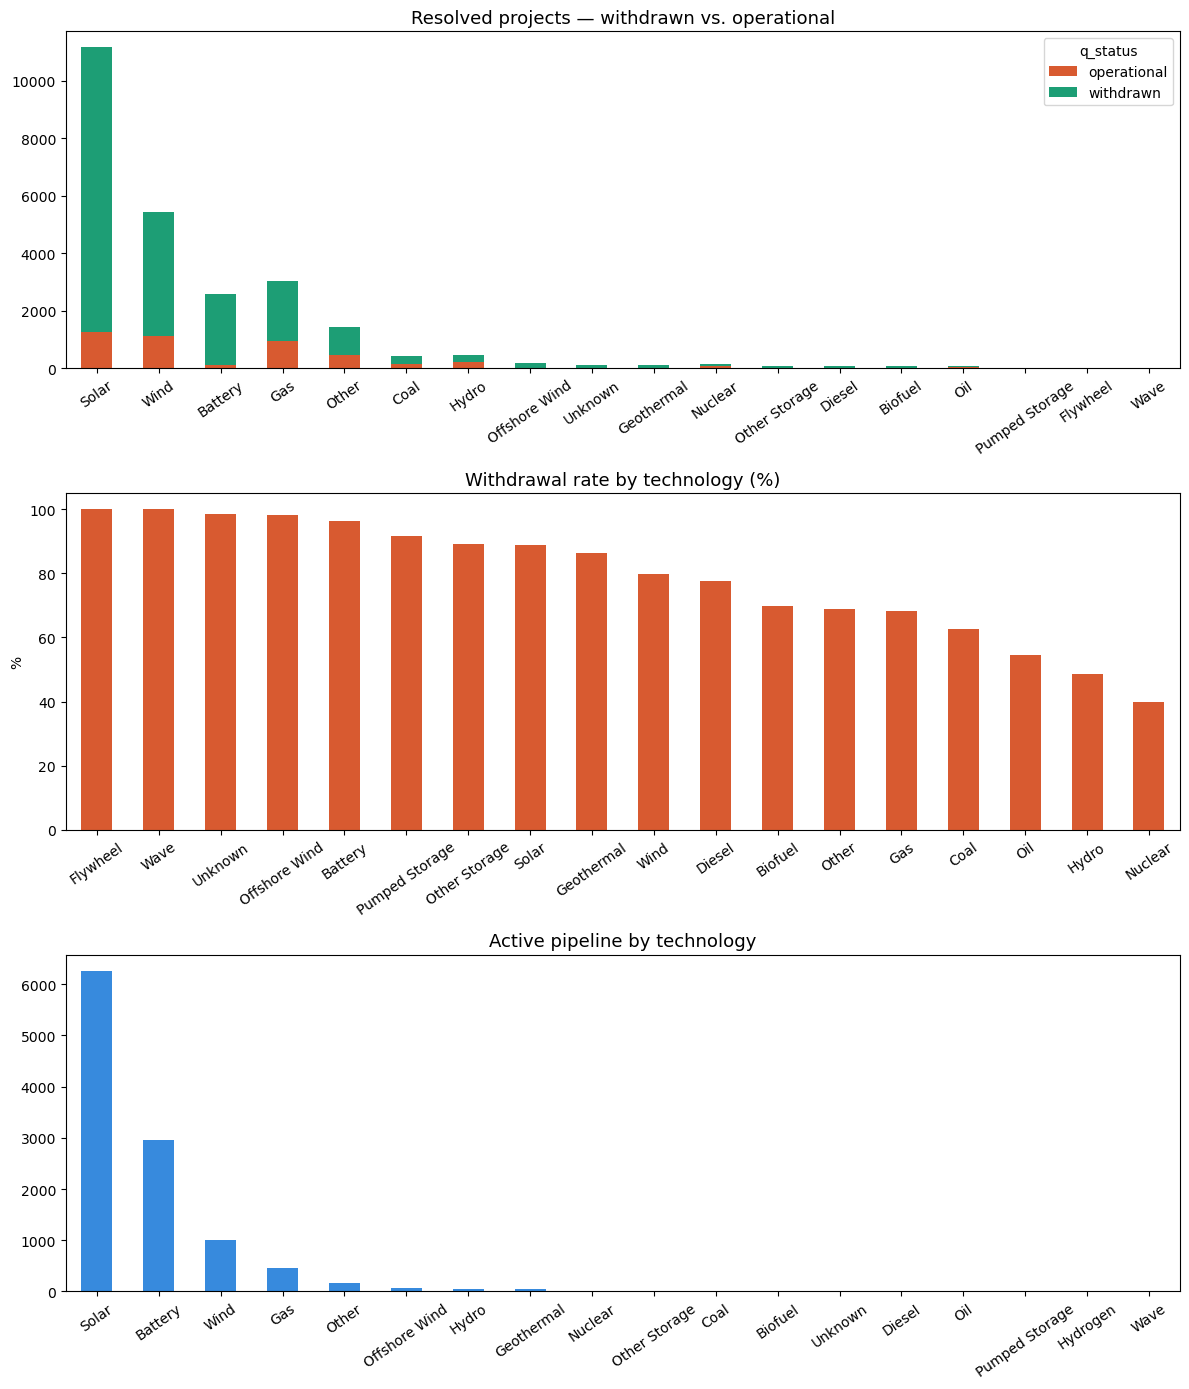

In [75]:
# Visual of types
import matplotlib.pyplot as plt

# counts per type1 by status
type_status = resolved.groupby(['type1', 'q_status']).size().unstack(fill_value=0)
withdrawal_rate = (type_status['withdrawn'] / type_status.sum(axis=1) * 100).sort_values(ascending=False)

active_counts = active.groupby('type1').size().sort_values(ascending=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# panel 1 — stacked bar
type_status.sort_values('withdrawn', ascending=False).plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#D85A30', '#1D9E75'], edgecolor='none'
)
axes[0].set_title('Resolved projects — withdrawn vs. operational', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35)

# panel 2 — withdrawal rate
withdrawal_rate.plot(kind='bar', ax=axes[1], color='#D85A30', edgecolor='none')
axes[1].set_title('Withdrawal rate by technology (%)', fontsize=13)
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)

# panel 3 — active pipeline
active_counts.plot(kind='bar', ax=axes[2], color='#378ADD', edgecolor='none')
axes[2].set_title('Active pipeline by technology', fontsize=13)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('../outputs/queue_by_type1.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# for by type
clean_types = {
    'Solar', 'Wind', 'Battery', 'Hydro', 'Offshore Wind',
    'Geothermal', 'Nuclear', 'Pumped Storage', 'Other Storage',
    'Flywheel', 'Hydrogen', 'Wave'
}

resolved['energy_class'] = resolved['type1'].apply(
    lambda x: 'Clean' if x in clean_types else 'Dirty'
)
active['energy_class'] = active['type1'].apply(
    lambda x: 'Clean' if x in clean_types else 'Dirty'
)

# quick sanity check
print(resolved.groupby('energy_class')['withdrawn'].value_counts())

energy_class  withdrawn
Clean         1            17354
              0             2803
Dirty         1             3567
              0             1629
Name: count, dtype: int64


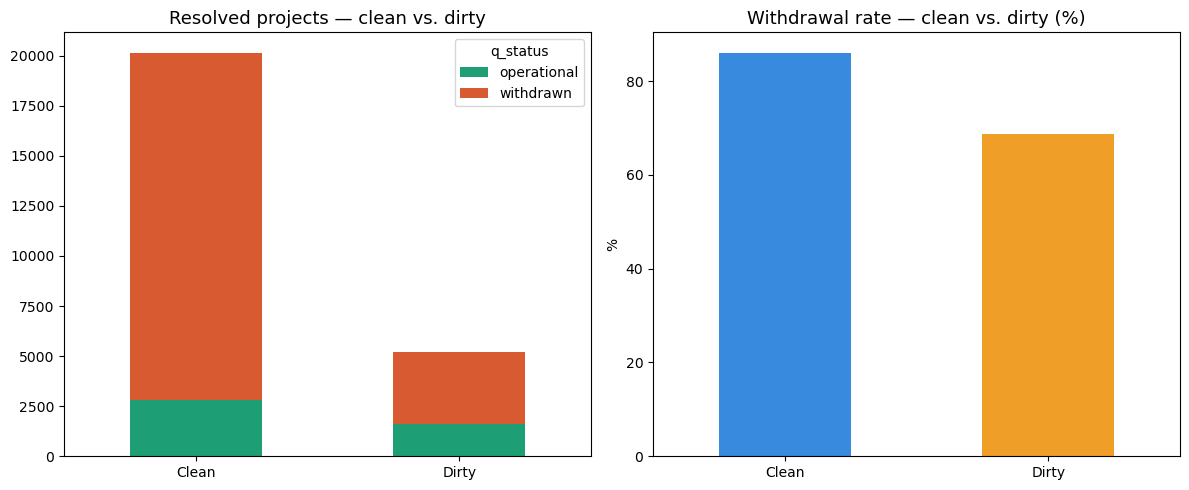

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# resolved — stacked by outcome
class_status = resolved.groupby(['energy_class', 'q_status']).size().unstack(fill_value=0)
class_status.plot(kind='bar', stacked=True, ax=axes[0],
    color=['#1D9E75', '#D85A30'], edgecolor='none')
axes[0].set_title('Resolved projects — clean vs. dirty', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# withdrawal rate comparison
wr = (class_status['withdrawn'] / class_status.sum(axis=1) * 100)
wr.plot(kind='bar', ax=axes[1], color=['#378ADD', '#EF9F27'], edgecolor='none')
axes[1].set_title('Withdrawal rate — clean vs. dirty (%)', fontsize=13)
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/clean_vs_dirty.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering

To include:
1. Year project entered queue
2. Days spent waiting before status update
3. Any interconnection agreements
4. Lead time for proposed project vs. online date
5. Project size in terms of megawatt capacity
6. clean vs. dirty flag (energy type)
7. queue congestion - how many projects entered the same year

In [78]:
# 1 — year project entered queue (you have this already as q_year, good)

# 2 — days spent waiting before withdrawal or operation
resolved['days_in_queue'] = (
    resolved['wd_date'].fillna(resolved['on_date']) - resolved['q_date']
).dt.days

# 3 — did the project ever sign an interconnection agreement?
resolved['has_ia'] = resolved['ia_date'].notna().astype(int)

# 4 — lead time: how far in the future was the proposed online date?
resolved['prop_lead_days'] = (
    resolved['prop_date'] - resolved['q_date']
).dt.days

# 5 — project size (mw1 is your primary capacity column)
# already exists as mw1, just make sure nulls are handled
resolved['mw1'] = resolved['mw1'].fillna(resolved['mw1'].median())

# 6 — clean vs dirty flag (you already made this)
# energy_class -> encode as binary
resolved['is_clean'] = (resolved['energy_class'] == 'Clean').astype(int)

# 7 — queue congestion: how many projects entered the same region in the same year?
congestion = (resolved.groupby(['region', 'q_year'])['q_id']
              .transform('count'))
resolved['region_year_congestion'] = congestion

# quick check
cols = ['days_in_queue', 'has_ia', 'prop_lead_days', 'mw1', 'is_clean', 'region_year_congestion']
print(resolved[cols].describe())
print("\nNulls:\n", resolved[cols].isna().sum())

       days_in_queue        has_ia  prop_lead_days           mw1  \
count   11887.000000  25353.000000    18067.000000  25353.000000   
mean      919.195592      0.054747     1336.076106    168.476318   
std       895.412401      0.227490     1939.321256    275.168338   
min     -2433.000000      0.000000    -8798.000000    -75.000000   
25%       259.000000      0.000000      700.000000     20.000000   
50%       651.000000      0.000000     1137.000000     80.000000   
75%      1358.000000      0.000000     1574.000000    200.000000   
max      7356.000000      1.000000    18013.000000  16875.000000   

           is_clean  region_year_congestion  
count  25353.000000            24908.000000  
mean       0.795054              228.965232  
std        0.403670              173.851846  
min        0.000000                1.000000  
25%        1.000000               91.000000  
50%        1.000000              192.000000  
75%        1.000000              328.000000  
max        1.000000

In [79]:
## CLEANING
pd.set_option('future.no_silent_downcasting', True)

# use np.nan instead of pd.NaT for numeric columns
resolved.loc[resolved['days_in_queue'] < 0, 'days_in_queue'] = np.nan
resolved.loc[resolved['mw1'] < 0, 'mw1'] = np.nan
resolved.loc[resolved['prop_lead_days'] < 0, 'prop_lead_days'] = np.nan

# impute with regional median, then global fallback
resolved['days_in_queue'] = (resolved.groupby('region')['days_in_queue']
    .transform(lambda x: x.fillna(x.median()))
    .infer_objects(copy=False))
resolved['days_in_queue'] = resolved['days_in_queue'].fillna(resolved['days_in_queue'].median())

resolved['prop_lead_days'] = resolved['prop_lead_days'].fillna(resolved['prop_lead_days'].median())
resolved['mw1'] = resolved['mw1'].fillna(resolved['mw1'].median())
resolved['region_year_congestion'] = resolved['region_year_congestion'].fillna(resolved['region_year_congestion'].median())

resolved['q_year'] = resolved['q_year'].fillna(resolved['q_year'].mode()[0]).astype(int)


Next, I set up my feature matrix. 

I include the seven features above, plus  ... 

In [80]:
from sklearn.preprocessing import LabelEncoder

# encode categoricals
le_region = LabelEncoder()
le_type = LabelEncoder()

resolved['region_enc'] = le_region.fit_transform(resolved['region'].fillna('Unknown'))
resolved['type1_enc'] = le_type.fit_transform(resolved['type1'].fillna('Unknown'))

# final feature set
features = [
    'mw1',
    'q_year',
    'days_in_queue',
    'has_ia',
    'prop_lead_days',
    'is_clean',
    'region_year_congestion',
    'region_enc',
    'type1_enc'
]

X = resolved[features]
y = resolved['withdrawn']

print(f"Feature matrix shape: {X.shape}")
print(f"\nClass balance:\n{y.value_counts()}")
print(f"\nAny remaining nulls:\n{X.isna().sum()}")

Feature matrix shape: (25353, 9)

Class balance:
withdrawn
1    20921
0     4432
Name: count, dtype: int64

Any remaining nulls:
mw1                       0
q_year                    0
days_in_queue             0
has_ia                    0
prop_lead_days            0
is_clean                  0
region_year_congestion    0
region_enc                0
type1_enc                 0
dtype: int64


Train: 16447 | Test: 8906
Train withdrawal rate: 77.4%
Test withdrawal rate:  91.9%


/opt/anaconda3/envs/dsan/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression  |  ROC-AUC: 0.8190
              precision    recall  f1-score   support

 Operational       0.31      0.62      0.41       722
   Withdrawn       0.96      0.88      0.92      8184

    accuracy                           0.86      8906
   macro avg       0.64      0.75      0.67      8906
weighted avg       0.91      0.86      0.88      8906


Decision Tree  |  ROC-AUC: 0.7658
              precision    recall  f1-score   support

 Operational       0.32      0.53      0.40       722
   Withdrawn       0.96      0.90      0.93      8184

    accuracy                           0.87      8906
   macro avg       0.64      0.72      0.66      8906
weighted avg       0.90      0.87      0.89      8906


Random Forest  |  ROC-AUC: 0.8861
              precision    recall  f1-score   support

 Operational       0.50      0.54      0.52       722
   Withdrawn       0.96      0.95      0.96      8184

    accuracy                           0.92      8906
   macro avg     

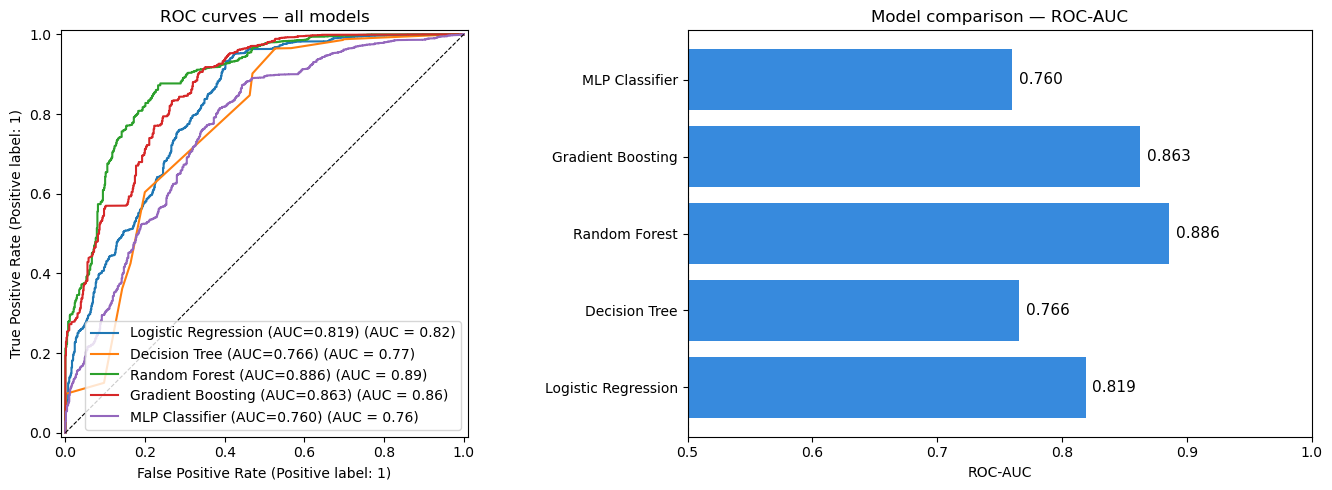

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import numpy as np

# temporal train/test split — train on pre-2019, test on 2019-2024
train = resolved[resolved['q_year'] < 2019]
test  = resolved[resolved['q_year'] >= 2019]

X_train = train[features]
y_train = train['withdrawn']
X_test  = test[features]
y_test  = test['withdrawn']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train withdrawal rate: {y_train.mean():.1%}")
print(f"Test withdrawal rate:  {y_test.mean():.1%}")

# scale for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- define models ---
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'MLP Classifier':      MLPClassifier(hidden_layer_sizes=(64, 32, 16), activation='relu', max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=42, verbose=False)
}

# --- train and evaluate ---
results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models.items():
    # use scaled data for logistic regression only
    Xtr = X_train_sc if name == ['Logistic Regression', 'MLP Classifier'] else X_train
    Xte = X_test_sc  if name == ['Logistic Regression', 'MLP Classifier'] else X_test
    
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'auc':    auc
    }
    
    print(f"\n{'='*40}")
    print(f"{name}  |  ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Operational', 'Withdrawn']))
    
    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_proba, name=f"{name} (AUC={auc:.3f})", ax=axes[0])

# --- AUC comparison bar chart ---
auc_scores = {k: v['auc'] for k, v in results.items()}
axes[1].barh(list(auc_scores.keys()), list(auc_scores.values()), color='#378ADD', edgecolor='none')
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Model comparison — ROC-AUC')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
for i, (k, v) in enumerate(auc_scores.items()):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=11)

axes[0].set_title('ROC curves — all models')
axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

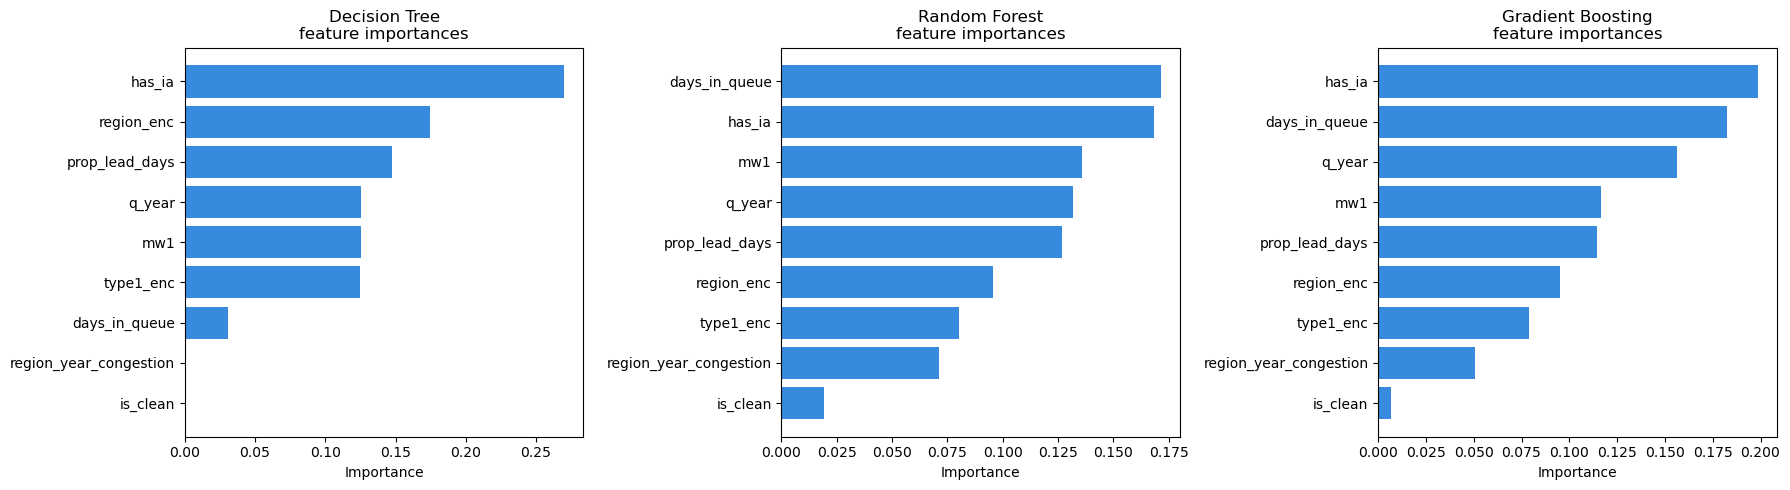

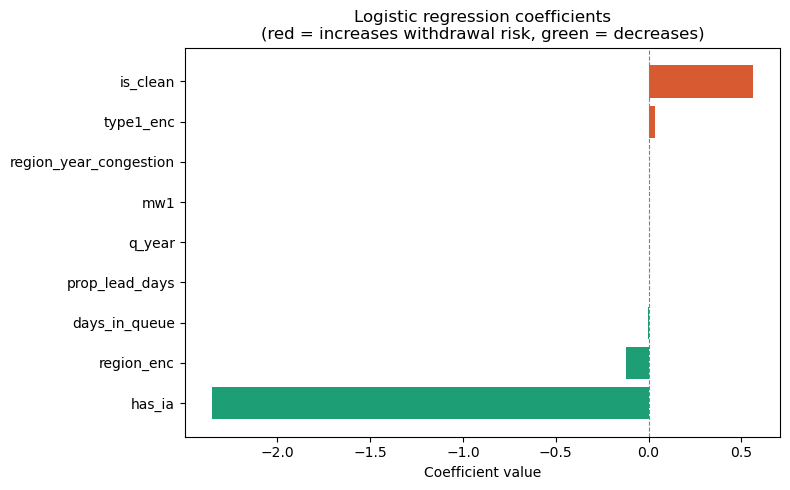

Running SHAP on best model: Random Forest


<Figure size 640x480 with 0 Axes>

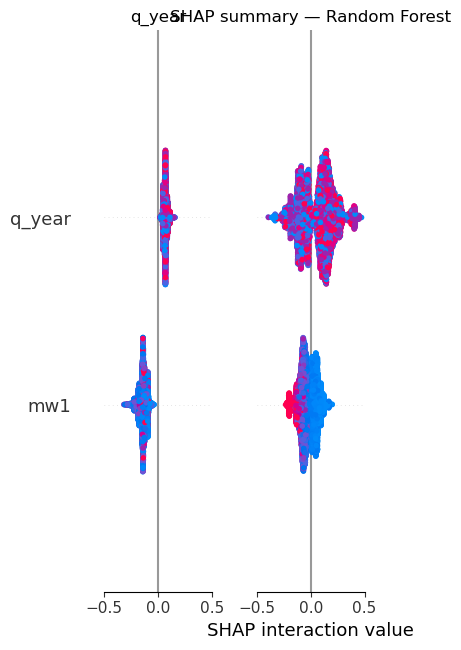

<Figure size 640x480 with 0 Axes>

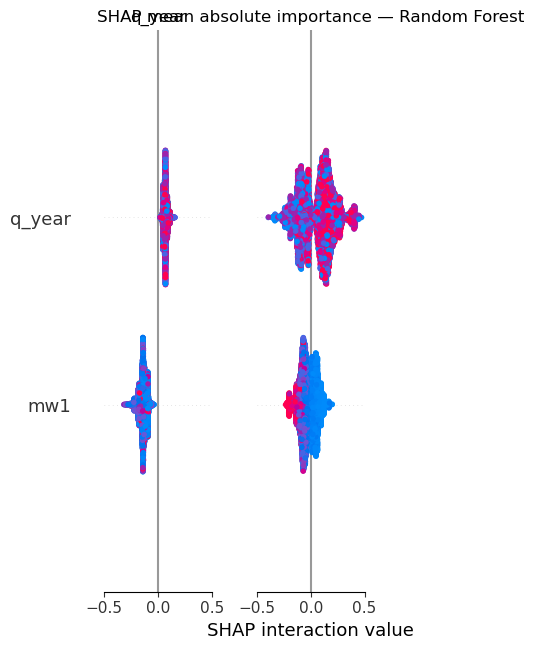

In [82]:
import shap

# --- 1. Feature importances for all tree-based models ---
tree_models = {k: v for k, v in results.items() if k not in ['Logistic Regression', 'MLP Classifier']}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, tree_models.items()):
    importances = res['model'].feature_importances_
    idx = np.argsort(importances)
    ax.barh([features[i] for i in idx], importances[idx], color='#378ADD', edgecolor='none')
    ax.set_title(f'{name}\nfeature importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Logistic regression coefficients ---
lr = results['Logistic Regression']['model']
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#D85A30' if c > 0 else '#1D9E75' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Logistic regression coefficients\n(red = increases withdrawal risk, green = decreases)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('../outputs/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. SHAP values for best model (swap in whichever won) ---
best_name = max(auc_scores, key=auc_scores.get)
best_model = results[best_name]['model']
print(f"Running SHAP on best model: {best_name}")

# use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# for binary classification shap_values may be a list — take class 1 (withdrawn)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# summary plot — shows direction + magnitude per feature
plt.figure()
shap.summary_plot(sv, X_test, feature_names=features, show=False)
plt.title(f'SHAP summary — {best_name}')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# bar plot — mean absolute SHAP (pure importance, no direction)
plt.figure()
shap.summary_plot(sv, X_test, feature_names=features, plot_type='bar', show=False)
plt.title(f'SHAP mean absolute importance — {best_name}')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

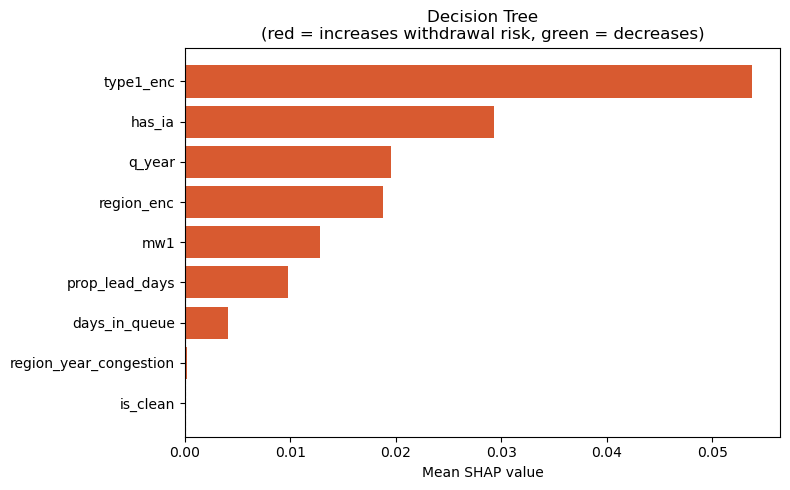

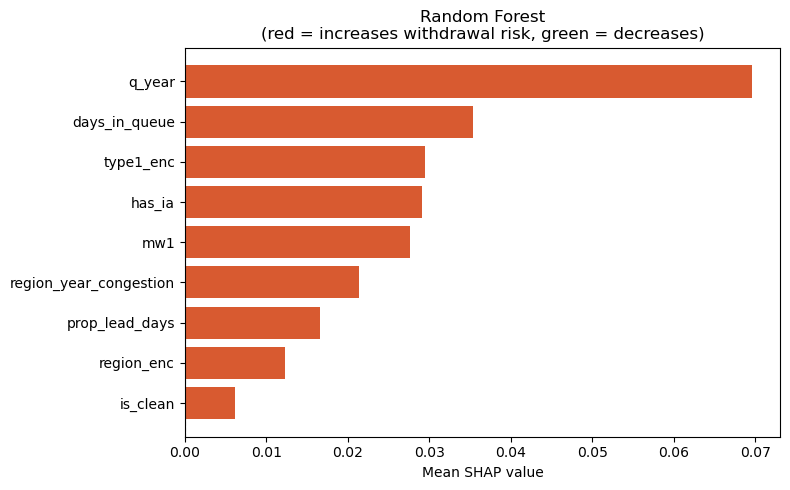

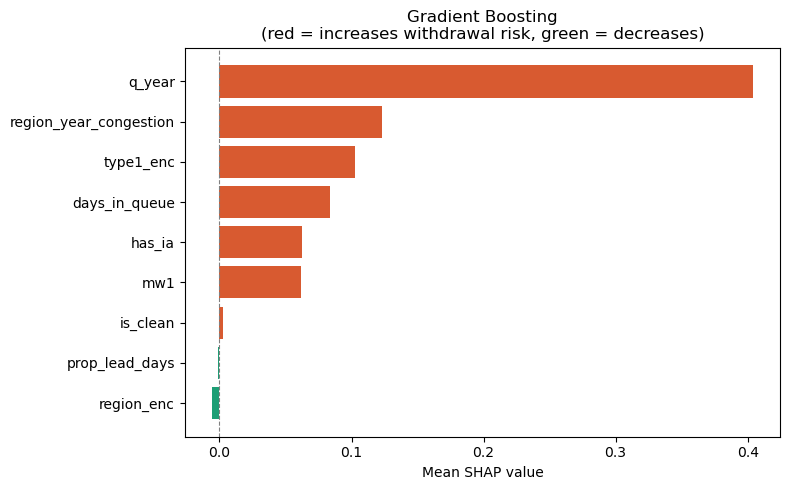

In [83]:
for name, res in tree_models.items():
    explainer = shap.TreeExplainer(res['model'])
    shap_values = explainer.shap_values(X_test)
    
    # handle both shapes
    if np.array(shap_values).ndim == 3:
        sv = shap_values[:, :, 1]  # 3D — slice last axis for class 1
    else:
        sv = shap_values           # 2D — already correct for gradient boosting
    
    mean_shap = pd.DataFrame({
        'feature': features,
        'mean_shap': sv.mean(axis=0)
    }).sort_values('mean_shap')
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#D85A30' if v > 0 else '#1D9E75' for v in mean_shap['mean_shap']]
    ax.barh(mean_shap['feature'], mean_shap['mean_shap'], color=colors, edgecolor='none')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{name}\n(red = increases withdrawal risk, green = decreases)')
    ax.set_xlabel('Mean SHAP value')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_direction_{name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [84]:
print(X_train.dtypes)
print(X_train.isnull().sum())

mw1                       float64
q_year                      int64
days_in_queue             float64
has_ia                      int64
prop_lead_days            float64
is_clean                    int64
region_year_congestion    float64
region_enc                  int64
type1_enc                   int64
dtype: object
mw1                       0
q_year                    0
days_in_queue             0
has_ia                    0
prop_lead_days            0
is_clean                  0
region_year_congestion    0
region_enc                0
type1_enc                 0
dtype: int64


In [85]:
resolved['mw1'] = pd.to_numeric(resolved['mw1'], errors='coerce')
resolved['mw1'] = resolved['mw1'].fillna(resolved['mw1'].median())

train = resolved[resolved['q_year'] < 2019]
test  = resolved[resolved['q_year'] >= 2019]

X_train = train[features].astype(float)
X_test  = test[features].astype(float)

print(X_train.dtypes)
print("Any nulls:", X_train.isnull().sum().sum())

mw1                       float64
q_year                    float64
days_in_queue             float64
has_ia                    float64
prop_lead_days            float64
is_clean                  float64
region_year_congestion    float64
region_enc                float64
type1_enc                 float64
dtype: object
Any nulls: 0


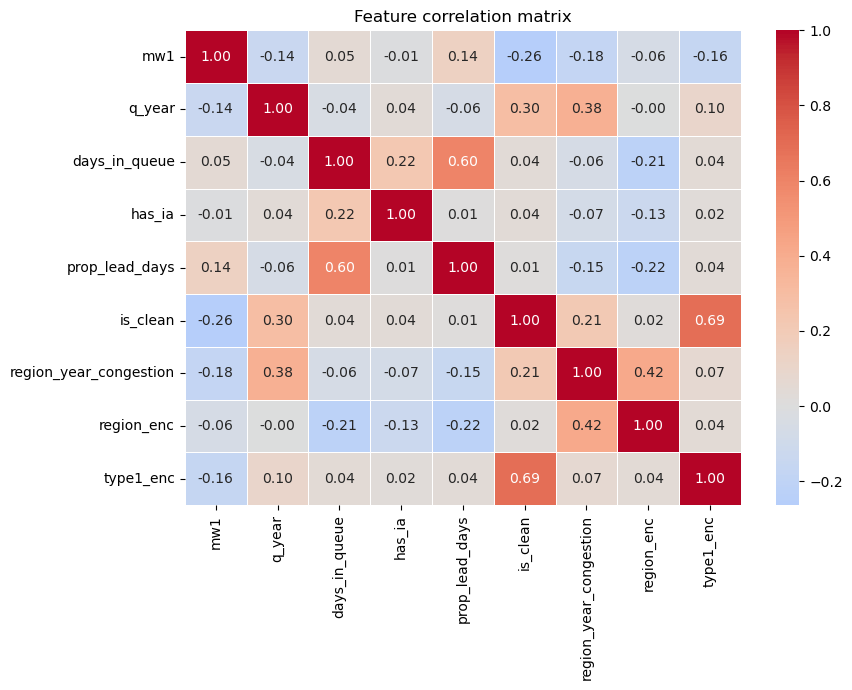

                  feature        VIF
1                  q_year  14.172246
8               type1_enc  13.635286
5                is_clean   7.989813
7              region_enc   5.999201
6  region_year_congestion   4.675663
2           days_in_queue   3.715993
4          prop_lead_days   2.618184
0                     mw1   1.481460
3                  has_ia   1.167466


In [86]:
# check for multicollinearity

import seaborn as sns

corr = X_train.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# VIF scores — formal multicollinearity test for logistic regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame({
    'feature': features,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif)

Logistic Regression | Brier score: 0.1256
Decision Tree | Brier score: 0.1498
Random Forest | Brier score: 0.0862
Gradient Boosting | Brier score: 0.0496
MLP Classifier | Brier score: 0.0785


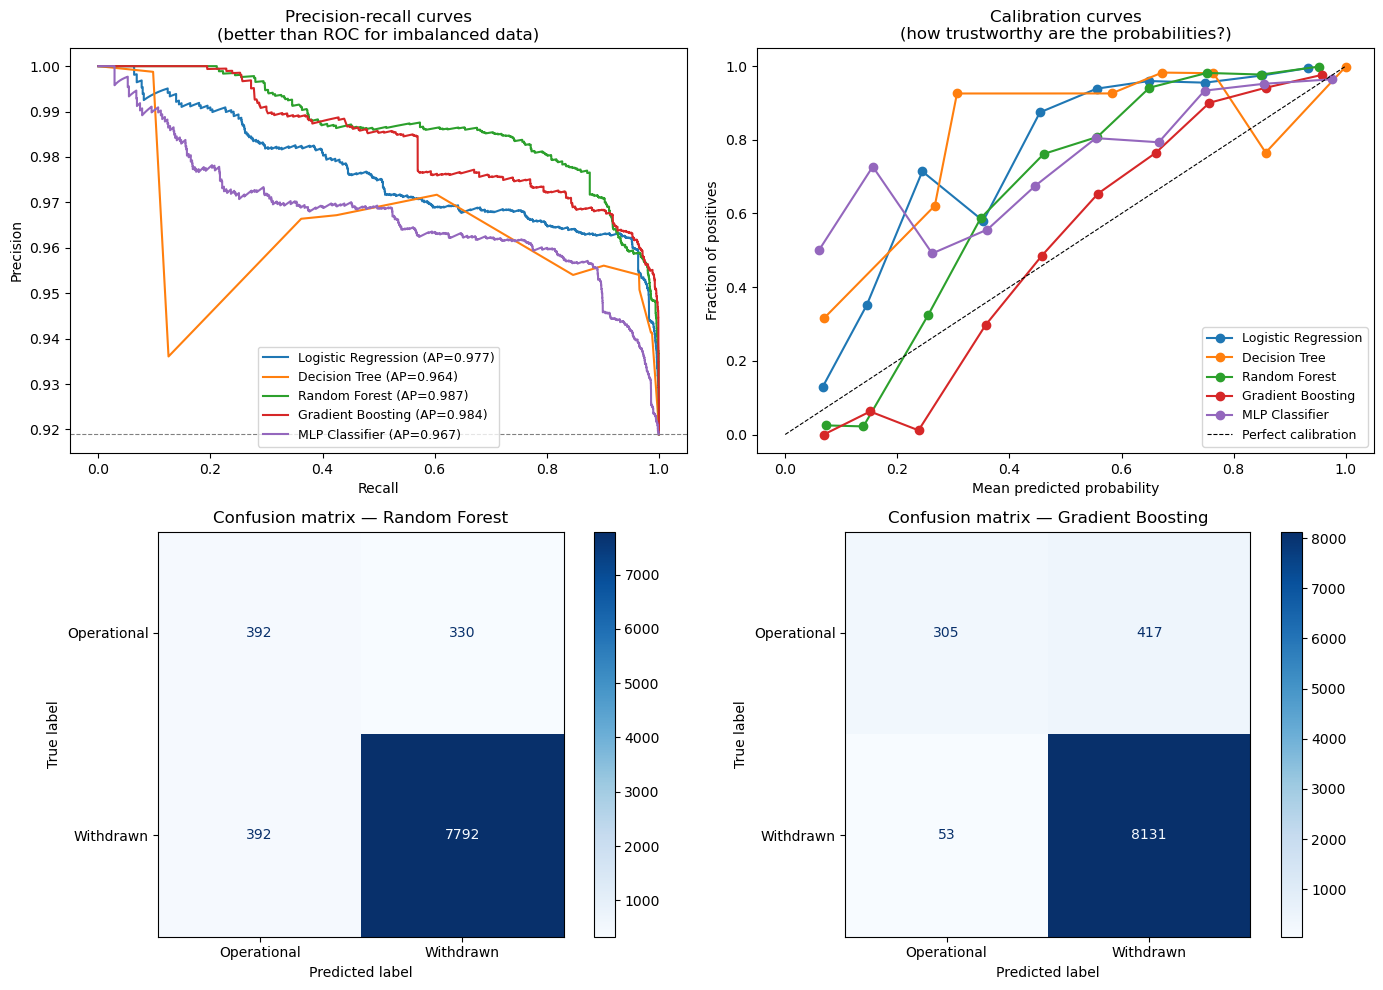

In [87]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay, brier_score_loss)
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for name, res in results.items():
    y_proba = res['y_proba']
    y_pred  = res['y_pred']
    
    # 1 — precision-recall curve (better than ROC for imbalanced classes)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[0,0].plot(recall, precision, label=f'{name} (AP={ap:.3f})')
    
    # 2 — calibration curve (is the model's confidence well-calibrated?)
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
    axes[0,1].plot(mean_pred, frac_pos, marker='o', label=name)
    
    # 3 — brier score (lower = better probabilistic predictions)
    bs = brier_score_loss(y_test, y_proba)
    print(f"{name} | Brier score: {bs:.4f}")

# format precision-recall plot
axes[0,0].set_xlabel('Recall')
axes[0,0].set_ylabel('Precision')
axes[0,0].set_title('Precision-recall curves\n(better than ROC for imbalanced data)')
axes[0,0].legend(fontsize=9)
baseline = y_test.mean()
axes[0,0].axhline(baseline, color='gray', linestyle='--', linewidth=0.8, label=f'Baseline ({baseline:.2f})')

# format calibration plot
axes[0,1].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Perfect calibration')
axes[0,1].set_xlabel('Mean predicted probability')
axes[0,1].set_ylabel('Fraction of positives')
axes[0,1].set_title('Calibration curves\n(how trustworthy are the probabilities?)')
axes[0,1].legend(fontsize=9)

# 4 — confusion matrices for best two models
best_two = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:2]
for ax, (name, res) in zip([axes[1,0], axes[1,1]], best_two):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=['Operational', 'Withdrawn'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion matrix — {name}')

plt.tight_layout()
plt.savefig('../outputs/additional_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Geospatial Analysis/Visualization

In [88]:
print(resolved.columns.tolist())
print(resolved[['county', 'state', 'fips_codes', 'region']].head(10))
print(resolved[['county', 'state', 'fips_codes', 'region']].isnull().sum())

print(active[['county', 'state', 'fips_codes', 'region']].isnull().sum())

['q_id', 'q_status', 'q_date', 'prop_date', 'on_date', 'wd_date', 'ia_date', 'IA_status_raw', 'IA_status_clean', 'county', 'state', 'county_state_pairs', 'fips_codes', 'poi_name', 'region', 'project_name', 'utility', 'entity', 'developer', 'cluster', 'service', 'project_type', 'type1', 'type2', 'type3', 'mw1', 'mw2', 'mw3', 'type_clean', 'q_year', 'prop_year', 'withdrawn', 'energy_class', 'days_in_queue', 'has_ia', 'prop_lead_days', 'is_clean', 'region_year_congestion', 'region_enc', 'type1_enc']
     county state  fips_codes region
0  Coconino    AZ      4005.0   West
1    Navajo    AZ      4017.0   West
2      Yuma    AZ      4027.0   West
3  Maricopa    AZ      4013.0   West
4  San Juan    NM     35045.0   West
5  Coconino    AZ      4005.0   West
6  Maricopa    AZ      4013.0   West
7  Maricopa    AZ      4013.0   West
8  Maricopa    AZ      4013.0   West
9  Maricopa    AZ      4013.0   West
county        2310
state           79
fips_codes    3024
region           0
dtype: int64
co

In [89]:
# if not already installed
# pip install geopandas mapclassify
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
import numpy as np
import pandas as pd

# download US county shapefile from Census TIGER
url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_5m.zip"
counties = gpd.read_file(url)

# standardize FIPS — Census uses string with leading zeros
counties['fips'] = counties['STATEFP'] + counties['COUNTYFP']
counties['fips'] = counties['fips'].astype(int)

print(counties[['fips', 'NAME', 'STATEFP']].head())
print(f"Counties loaded: {len(counties)}")

    fips     NAME STATEFP
0  13233     Polk      13
1  21023  Bracken      21
2  28153    Wayne      28
3  42001    Adams      42
4   4007     Gila      04
Counties loaded: 3235


In [90]:
# rebuild engineered features on active df -- later, just do this first
# fix 1 — rebuild engineered features on active df
active['days_in_queue'] = (
    active['wd_date'].fillna(active['on_date']) - active['q_date']
).dt.days
active.loc[active['days_in_queue'] < 0, 'days_in_queue'] = np.nan

active['has_ia'] = active['ia_date'].notna().astype(int)

active['prop_lead_days'] = (active['prop_date'] - active['q_date']).dt.days
active.loc[active['prop_lead_days'] < 0, 'prop_lead_days'] = np.nan

active['mw1'] = pd.to_numeric(active['mw1'], errors='coerce')
active['is_clean'] = (active['energy_class'] == 'Clean').astype(int)
active['q_year'] = pd.to_datetime(active['q_date']).dt.year

congestion_active = active.groupby(['region', 'q_year'])['q_id'].transform('count')
active['region_year_congestion'] = congestion_active

active['region_enc'] = le_region.transform(active['region'].fillna('Unknown'))

# fix 2 — handle unseen labels in type1 by mapping to 'Other' before encoding
known_types = set(le_type.classes_)
active['type1_safe'] = active['type1'].apply(
    lambda x: x if x in known_types else 'Other'
)
active['type1_enc'] = le_type.transform(active['type1_safe'].fillna('Other'))

# impute nulls using resolved medians
for col in ['days_in_queue', 'prop_lead_days', 'mw1', 'region_year_congestion']:
    active[col] = active[col].fillna(resolved[col].median())

active['q_year'] = active['q_year'].fillna(resolved['q_year'].mode()[0]).astype(int)

# verify
print("Active nulls:\n", active[features].isnull().sum())
print("\nActive feature dtypes:\n", active[features].dtypes)

Active nulls:
 mw1                       0
q_year                    0
days_in_queue             0
has_ia                    0
prop_lead_days            0
is_clean                  0
region_year_congestion    0
region_enc                0
type1_enc                 0
dtype: int64

Active feature dtypes:
 mw1                       float64
q_year                      int64
days_in_queue             float64
has_ia                      int64
prop_lead_days            float64
is_clean                    int64
region_year_congestion    float64
region_enc                  int64
type1_enc                   int64
dtype: object


In [91]:
# add predicted withdrawal probability to resolved df
resolved_map = resolved.copy()
resolved_map['pred_proba'] = results['Random Forest']['model'].predict_proba(X_test.reindex(resolved_map.index, fill_value=0))[:, 1]

# get predictions for ALL resolved projects
X_all = resolved[features].astype(float)
best_name = max(auc_scores, key=auc_scores.get)
best_model = results[best_name]['model']

resolved['pred_proba'] = best_model.predict_proba(X_all)[:, 1]
active['pred_proba']   = best_model.predict_proba(active[features].astype(float))[:, 1]

print(f"Using best model: {best_name}")
print(resolved['pred_proba'].describe())

Using best model: Random Forest
count    25353.000000
mean         0.671768
std          0.245865
min          0.003822
25%          0.550230
50%          0.727788
75%          0.862800
max          0.999053
Name: pred_proba, dtype: float64


In [92]:
# county-level aggregations for resolved projects
county_stats = resolved.groupby('fips_codes').agg(
    total_projects    = ('q_id', 'count'),
    actual_wr         = ('withdrawn', 'mean'),
    pred_wr           = ('pred_proba', 'mean'),
    total_mw          = ('mw1', 'sum'),
    clean_share       = ('is_clean', 'mean'),
    avg_days_in_queue = ('days_in_queue', 'mean')
).reset_index()
county_stats.columns.name = None
county_stats['fips_codes'] = county_stats['fips_codes'].astype(int)

# county-level for active projects — predicted risk for pipeline
active_county = active.groupby('fips_codes').agg(
    active_projects  = ('q_id', 'count'),
    active_pred_wr   = ('pred_proba', 'mean'),
    active_mw        = ('mw1', 'sum')
).reset_index()
active_county['fips_codes'] = active_county['fips_codes'].astype(int)

print(county_stats.head())
print(f"Counties with data: {len(county_stats)}")

   fips_codes  total_projects  actual_wr   pred_wr  total_mw  clean_share  \
0        1001              21   0.809524  0.816010   10805.0     0.333333   
1        1003              11   1.000000  0.818747    2455.0     0.727273   
2        1005               1   1.000000  0.832435      79.5     1.000000   
3        1009               5   1.000000  0.810275    2160.0     0.600000   
4        1011               1   1.000000  0.877098      79.0     1.000000   

   avg_days_in_queue  
0         247.357143  
1         923.545455  
2         522.000000  
3         320.700000  
4         327.000000  
Counties with data: 2419


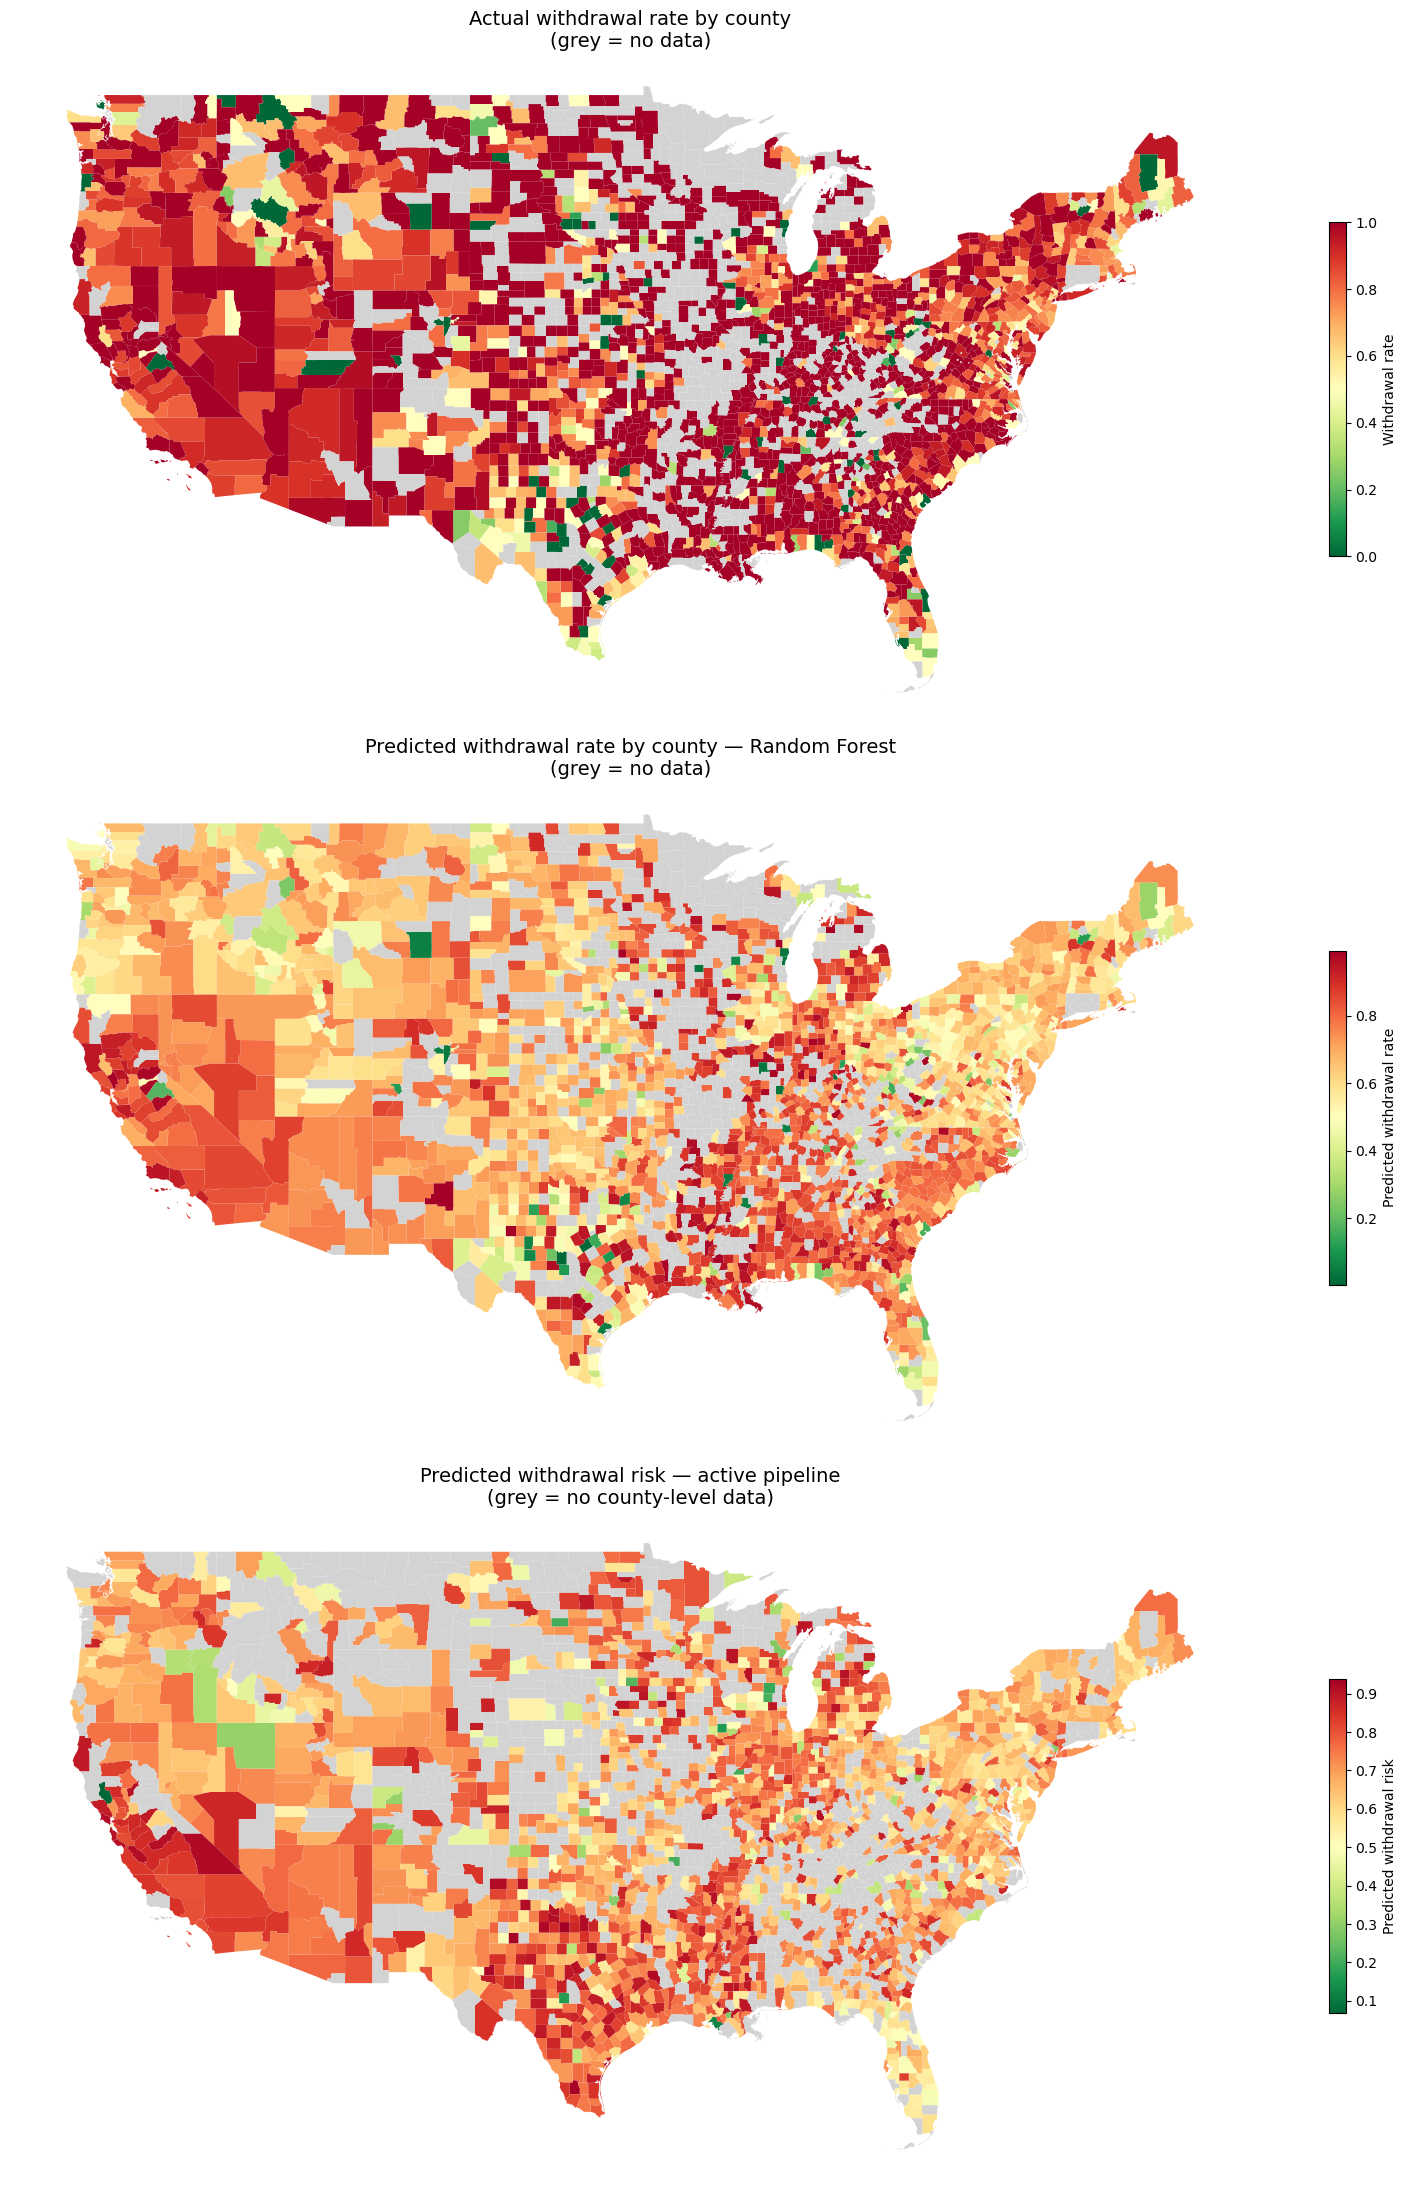

In [93]:
# merge with shapefile
geo = counties.merge(county_stats, left_on='fips', right_on='fips_codes', how='left')
geo_active = counties.merge(active_county, left_on='fips', right_on='fips_codes', how='left')

# drop Alaska, Hawaii, territories for cleaner CONUS map
conus = geo[~geo['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])]
conus_active = geo_active[~geo_active['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])]

# --- plot 3 maps ---
fig, axes = plt.subplots(3, 1, figsize=(16, 22))

# map 1 — actual withdrawal rate by county
conus.plot(column='actual_wr', ax=axes[0], cmap='RdYlGn_r',
           missing_kwds={'color': 'lightgrey'},
           legend=True, legend_kwds={'label': 'Withdrawal rate', 'shrink': 0.5})
axes[0].set_title('Actual withdrawal rate by county\n(grey = no data)', fontsize=14)
axes[0].axis('off')

# map 2 — predicted withdrawal rate by county
conus.plot(column='pred_wr', ax=axes[1], cmap='RdYlGn_r',
           missing_kwds={'color': 'lightgrey'},
           legend=True, legend_kwds={'label': 'Predicted withdrawal rate', 'shrink': 0.5})
axes[1].set_title(f'Predicted withdrawal rate by county — {best_name}\n(grey = no data)', fontsize=14)
axes[1].axis('off')

# map 3 — active pipeline risk
conus_active.plot(column='active_pred_wr', ax=axes[2], cmap='RdYlGn_r',
                  missing_kwds={'color': 'lightgrey'},
                  legend=True, legend_kwds={'label': 'Predicted withdrawal risk', 'shrink': 0.5})
axes[2].set_title('Predicted withdrawal risk — active pipeline\n(grey = no county-level data)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/geospatial_maps.png', dpi=150, bbox_inches='tight')
plt.show()

      region  total_projects  actual_wr   pred_wr       total_mw
0      CAISO            2199   0.896317  0.851307  519339.383321
1      ERCOT            1444   0.661357  0.623519  300716.970000
2     ISO-NE             882   0.751701  0.622708  106706.716464
3       MISO            2764   0.821997  0.652645  504138.460000
4      NYISO            1415   0.920848  0.688296  290916.910000
5        PJM            6080   0.803454  0.613408  677218.266800
6        SPP            1818   0.842134  0.645657  352598.437000
7  Southeast            2914   0.847632  0.750533  640528.304000
8       West            5837   0.834504  0.658125  879759.836540


/var/folders/vs/825z13d94t3bzpx7ndr7r59w0000gn/T/ipykernel_69156/224633386.py:12: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  region_map = counties.merge(


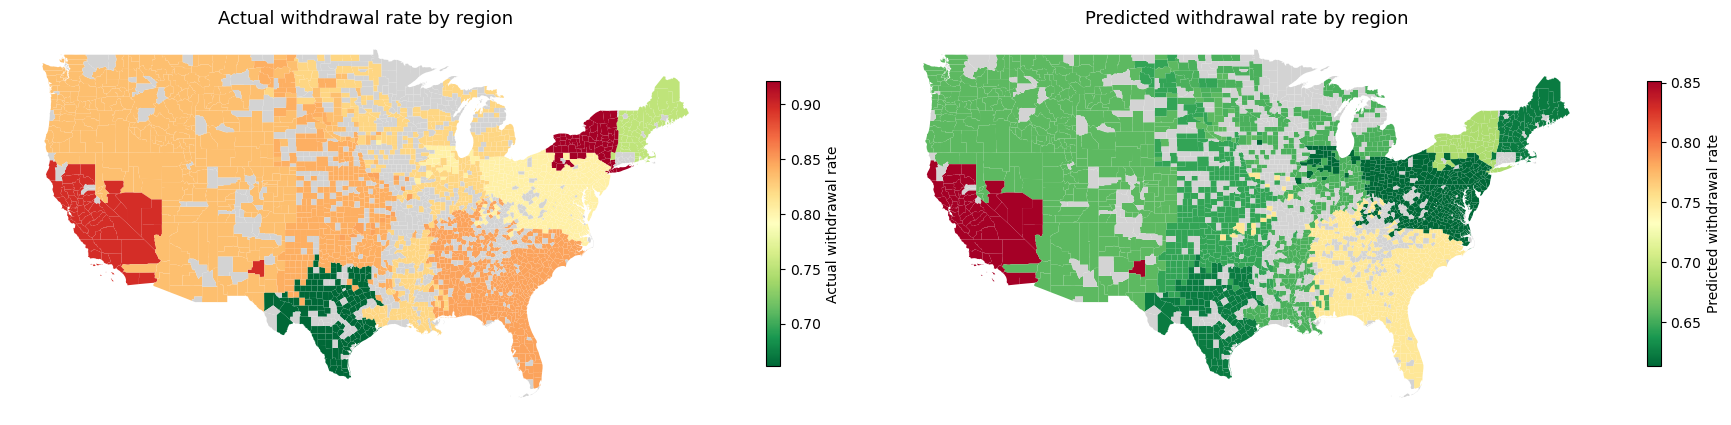

In [94]:
# aggregate to region level
region_stats = resolved.groupby('region').agg(
    total_projects = ('q_id', 'count'),
    actual_wr      = ('withdrawn', 'mean'),
    pred_wr        = ('pred_proba', 'mean'),
    total_mw       = ('mw1', 'sum')
).reset_index()

print(region_stats)

# merge region onto counties shapefile
region_map = counties.merge(
    resolved[['fips_codes', 'region']].dropna().drop_duplicates('fips_codes'),
    left_on='fips', right_on='fips_codes', how='left'
)
region_map = region_map.merge(region_stats, on='region', how='left')
region_conus = region_map[~region_map['STATEFP'].isin(['02','15','60','66','69','72','78'])]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

region_conus.plot(column='actual_wr', ax=axes[0], cmap='RdYlGn_r',
                  missing_kwds={'color': 'lightgrey'}, legend=True,
                  legend_kwds={'label': 'Actual withdrawal rate', 'shrink': 0.5})
axes[0].set_title('Actual withdrawal rate by region', fontsize=13)
axes[0].axis('off')

region_conus.plot(column='pred_wr', ax=axes[1], cmap='RdYlGn_r',
                  missing_kwds={'color': 'lightgrey'}, legend=True,
                  legend_kwds={'label': 'Predicted withdrawal rate', 'shrink': 0.5})
axes[1].set_title('Predicted withdrawal rate by region', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/map_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

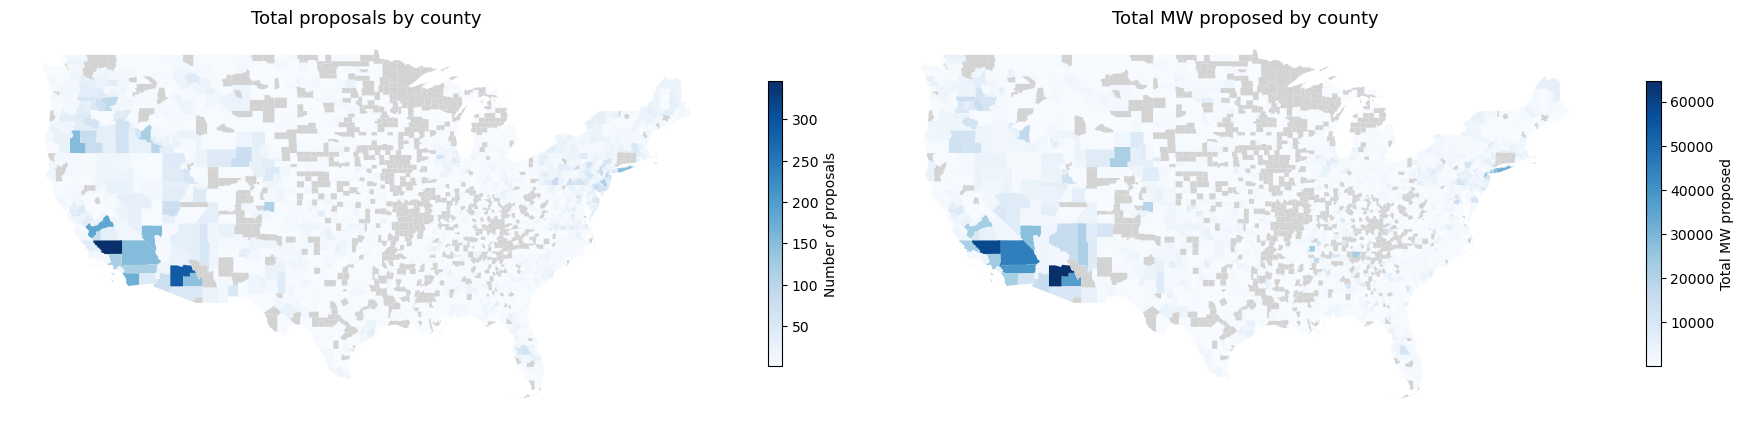

In [95]:
proposal_counts = resolved.groupby('fips_codes').agg(
    total_projects = ('q_id', 'count'),
    total_mw       = ('mw1', 'sum')
).reset_index()
proposal_counts['fips_codes'] = proposal_counts['fips_codes'].astype(int)

geo_proposals = counties.merge(proposal_counts, left_on='fips', right_on='fips_codes', how='left')
geo_proposals_conus = geo_proposals[~geo_proposals['STATEFP'].isin(['02','15','60','66','69','72','78'])]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

geo_proposals_conus.plot(column='total_projects', ax=axes[0], cmap='Blues',
                         missing_kwds={'color': 'lightgrey'}, legend=True,
                         legend_kwds={'label': 'Number of proposals', 'shrink': 0.5})
axes[0].set_title('Total proposals by county', fontsize=13)
axes[0].axis('off')

geo_proposals_conus.plot(column='total_mw', ax=axes[1], cmap='Blues',
                         missing_kwds={'color': 'lightgrey'}, legend=True,
                         legend_kwds={'label': 'Total MW proposed', 'shrink': 0.5})
axes[1].set_title('Total MW proposed by county', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/map_proposals.png', dpi=150, bbox_inches='tight')
plt.show()

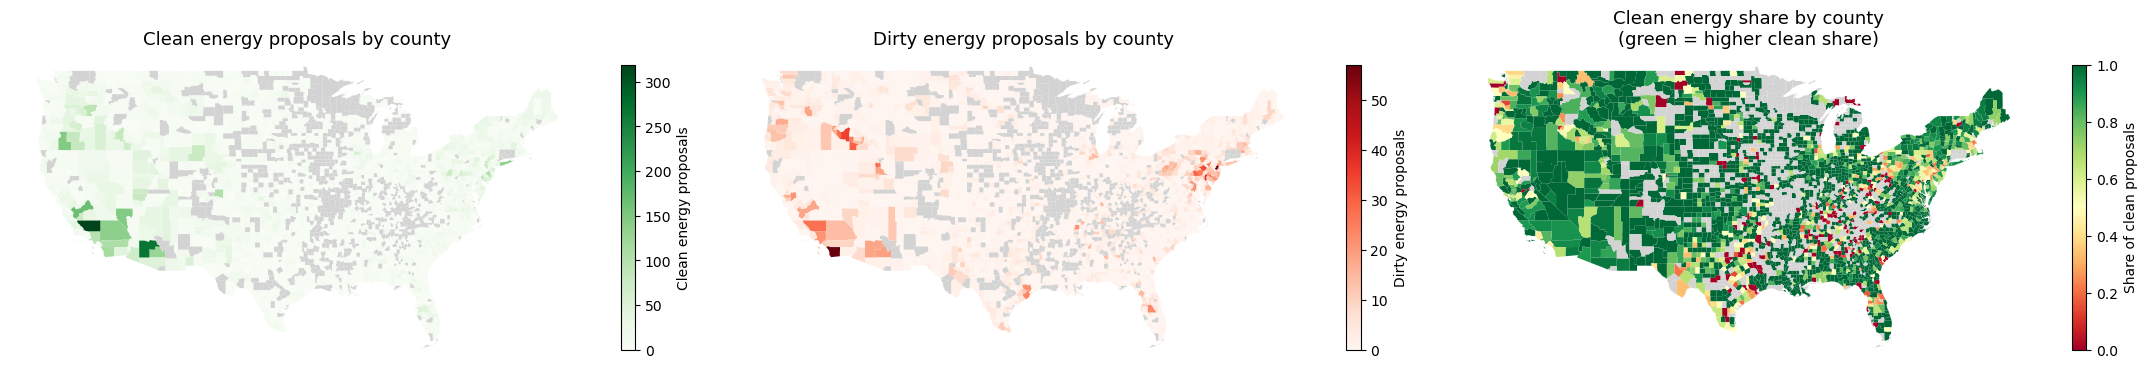

In [96]:
clean_county = resolved.groupby(['fips_codes', 'is_clean']).size().unstack(fill_value=0)
clean_county.columns = ['dirty_count', 'clean_count']
clean_county['total'] = clean_county['clean_count'] + clean_county['dirty_count']
clean_county['clean_share'] = clean_county['clean_count'] / clean_county['total']
clean_county = clean_county.reset_index()
clean_county['fips_codes'] = clean_county['fips_codes'].astype(int)

geo_clean = counties.merge(clean_county, left_on='fips', right_on='fips_codes', how='left')
geo_clean_conus = geo_clean[~geo_clean['STATEFP'].isin(['02','15','60','66','69','72','78'])]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

geo_clean_conus.plot(column='clean_count', ax=axes[0], cmap='Greens',
                     missing_kwds={'color': 'lightgrey'}, legend=True,
                     legend_kwds={'label': 'Clean energy proposals', 'shrink': 0.5})
axes[0].set_title('Clean energy proposals by county', fontsize=13)
axes[0].axis('off')

geo_clean_conus.plot(column='dirty_count', ax=axes[1], cmap='Reds',
                     missing_kwds={'color': 'lightgrey'}, legend=True,
                     legend_kwds={'label': 'Dirty energy proposals', 'shrink': 0.5})
axes[1].set_title('Dirty energy proposals by county', fontsize=13)
axes[1].axis('off')

geo_clean_conus.plot(column='clean_share', ax=axes[2], cmap='RdYlGn',
                     missing_kwds={'color': 'lightgrey'}, legend=True,
                     legend_kwds={'label': 'Share of clean proposals', 'shrink': 0.5})
axes[2].set_title('Clean energy share by county\n(green = higher clean share)', fontsize=13)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/map_clean_vs_dirty.png', dpi=150, bbox_inches='tight')
plt.show()

Final carbon code run and output to tracker file:

In [97]:
# stop tracker and get emissions
import csv
emissions = tracker.stop()

# define output file
log_file = "../outputs/codecarbon_log.csv"

# write header if file doesn't exist yet
if not os.path.exists(log_file):
    with open(log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp",
                         "emissions_kg_co2e"])

# append a new row for this run
with open(log_file, "a", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        round(emissions, 8)
    ])

print(f"Carbon cost this run: {emissions:.6f} kg CO2e")
print(f"Logged to: {log_file}")


TypeError: type NoneType doesn't define __round__ method

In [98]:
print(f"Type: {type(emissions)}")
print(f"Value: {emissions}")

Type: <class 'NoneType'>
Value: None


In [66]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(log_level="error")
tracker.start()

# simple test computation
import time
time.sleep(2)

emissions = tracker.stop()
print(f"Type: {type(emissions)}")
print(f"Value: {emissions}")

Type: <class 'float'>
Value: 1.2870306698010215e-05
